# Part 2 — Bayesian Sentiment Analysis (IMDB Reviews)

**Question we answer:** given that a movie review contains a particular word, what is the
probability the review is *positive*?  In symbols, for each keyword we compute

$$P(\text{Positive}\mid \text{keyword}) = \frac{P(\text{keyword}\mid \text{Positive})\; P(\text{Positive})}{P(\text{keyword})}$$

**Our decision (only one conditional, as required):** we compute **P(Positive | keyword)** — *not* P(Negative | keyword).

**Keywords chosen**

| Sentiment we expect | Keywords |
|---|---|
| Positive | wonderful, excellent, brilliant |
| Negative | terrible, awful, boring |

We chose words with strong, one-sided polarity that rarely appear in the opposite class.
We then compute the posterior for **all six** — the positive words should score high and the
negative words low. That contrast is the demonstration that the method works.

Only the Python **standard library** is used for the computation (no ML libraries).

## The four quantities, as plain counts

Every term in Bayes' Theorem is just a fraction we count from the data:

| Term | Meaning | How we count it |
|---|---|---|
| **Prior** $P(\text{Positive})$ | share of reviews that are positive | positive reviews / all reviews |
| **Likelihood** $P(\text{kw}\mid\text{Positive})$ | of positive reviews, share containing the word | positive reviews with kw / positive reviews |
| **Marginal** $P(\text{kw})$ | share of *all* reviews containing the word | reviews with kw / all reviews |
| **Posterior** $P(\text{Positive}\mid\text{kw})$ | what we solve for | Likelihood × Prior / Marginal |

**Built-in sanity check:** if you expand the algebra, everything cancels and the posterior equals
*(positive reviews with the word) / (all reviews with the word)*. The notebook prints this check for
every keyword — if it ever says `False`, there is a bug.

In [1]:
import csv
from IPython.display import Markdown, display

In [2]:
def load_reviews(filepath):
    """Read the IMDB CSV -> list of (review_text, sentiment) tuples.
    The Kaggle file has two columns: 'review' and 'sentiment'."""
    reviews = []
    with open(filepath, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            reviews.append((row["review"], row["sentiment"]))
    return reviews

In [3]:
def tokenize(text):
    """Lowercase and split into whole words. Every non-letter (punctuation,
    digits, HTML like <br />) becomes a space, so 'Wonderful!' -> 'wonderful'.
    Whole-word matching: 'wonderful' will NOT match inside 'wonderfully'."""
    lowered = text.lower()
    cleaned = "".join(ch if ch.isalpha() else " " for ch in lowered)
    return cleaned.split()

In [5]:
def compute_counts(reviews, keywords):
    """One pass over the data, tallying every count Bayes needs."""
    total = 0
    positive_total = 0
    keyword_total = {kw: 0 for kw in keywords}
    keyword_and_positive = {kw: 0 for kw in keywords}

    for text, sentiment in reviews:
        total += 1
        is_positive = sentiment == "positive"
        if is_positive:
            positive_total += 1

        tokens = set(tokenize(text))          # set -> fast lookup
        for kw in keywords:
            if kw in tokens:
                keyword_total[kw] += 1
                if is_positive:
                    keyword_and_positive[kw] += 1

    return {
        "total": total,
        "positive_total": positive_total,
        "keyword_total": keyword_total,
        "keyword_and_positive": keyword_and_positive,
    }

In [6]:
def bayes_positive_given_keyword(counts, keyword):
    """Return prior, likelihood, marginal, posterior for P(Positive | keyword)."""
    total = counts["total"]
    positive_total = counts["positive_total"]
    kw_total = counts["keyword_total"][keyword]
    kw_and_pos = counts["keyword_and_positive"][keyword]

    if kw_total == 0:
        raise ValueError(f"'{keyword}' never appears; P(keyword) = 0.")

    prior      = positive_total / total          # P(Positive)
    likelihood = kw_and_pos / positive_total     # P(keyword | Positive)
    marginal   = kw_total / total                # P(keyword)
    posterior  = (likelihood * prior) / marginal # P(Positive | keyword)

    return {
        "prior": prior,
        "likelihood": likelihood,
        "marginal": marginal,
        "posterior": posterior,
        "direct_ratio": kw_and_pos / kw_total,   # sanity-check target
    }

In [7]:
def format_keyword_markdown(keyword, p):
    """Markdown table for one keyword."""
    return (
        f"### Keyword: `{keyword}`\n\n"
        f"| Quantity | Symbol | Value |\n"
        f"|---|---|---|\n"
        f"| Prior | P(Positive) | {p['prior']:.4f} |\n"
        f"| Likelihood | P('{keyword}' \\| Positive) | {p['likelihood']:.4f} |\n"
        f"| Marginal | P('{keyword}') | {p['marginal']:.4f} |\n"
        f"| **Posterior** | **P(Positive \\| '{keyword}')** | **{p['posterior']:.4f}** |\n"
    )

def format_summary_table(results):
    """One row per keyword, highest posterior first."""
    lines = ["| Keyword | Prior | Likelihood | Marginal | Posterior |",
             "|---|---|---|---|---|"]
    for kw, p in sorted(results.items(), key=lambda kv: -kv[1]["posterior"]):
        lines.append(f"| {kw} | {p['prior']:.4f} | {p['likelihood']:.4f} "
                     f"| {p['marginal']:.4f} | {p['posterior']:.4f} |")
    return "\n".join(lines)

## Load the data and set our keywords


In [8]:
from pathlib import Path

DATA_PATH = Path("IMDB Dataset.csv")

if not DATA_PATH.exists():
    DATA_PATH = Path.cwd() / "IMDB Dataset.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"CSV file not found. Expected it in the notebook folder or current working directory: {DATA_PATH}"
    )

KEYWORDS = ["wonderful", "excellent", "brilliant",   # positive-sentiment
            "terrible", "awful", "boring"]           # negative-sentiment

reviews = load_reviews(DATA_PATH)
counts = compute_counts(reviews, KEYWORDS)

print(f"Loaded {counts['total']} reviews "
      f"({counts['positive_total']} positive, "
      f"{counts['total'] - counts['positive_total']} negative)")
print(f"Using CSV path: {DATA_PATH}")

Loaded 50000 reviews (25000 positive, 25000 negative)
Using CSV path: IMDB Dataset.csv


## Bayes' Theorem for each keyword

The `Verification` line under each table confirms the posterior equals
(positive-with-word / all-with-word).

In [9]:
results = {}
for kw in KEYWORDS:
    probs = bayes_positive_given_keyword(counts, kw)
    results[kw] = probs
    display(Markdown(format_keyword_markdown(kw, probs)))
    ok = abs(probs["posterior"] - probs["direct_ratio"]) < 1e-9
    display(Markdown(f"*Verification (posterior == positive-with-word / all-with-word): "
                     f"**{ok}***"))

### Keyword: `wonderful`

| Quantity | Symbol | Value |
|---|---|---|
| Prior | P(Positive) | 0.5000 |
| Likelihood | P('wonderful' \| Positive) | 0.0903 |
| Marginal | P('wonderful') | 0.0556 |
| **Posterior** | **P(Positive \| 'wonderful')** | **0.8122** |


*Verification (posterior == positive-with-word / all-with-word): **True***

### Keyword: `excellent`

| Quantity | Symbol | Value |
|---|---|---|
| Prior | P(Positive) | 0.5000 |
| Likelihood | P('excellent' \| Positive) | 0.1147 |
| Marginal | P('excellent') | 0.0710 |
| **Posterior** | **P(Positive \| 'excellent')** | **0.8074** |


*Verification (posterior == positive-with-word / all-with-word): **True***

### Keyword: `brilliant`

| Quantity | Symbol | Value |
|---|---|---|
| Prior | P(Positive) | 0.5000 |
| Likelihood | P('brilliant' \| Positive) | 0.0635 |
| Marginal | P('brilliant') | 0.0418 |
| **Posterior** | **P(Positive \| 'brilliant')** | **0.7601** |


...

*Verification (posterior == positive-with-word / all-with-word): **True***

### Keyword: `awful`

| Quantity | Symbol | Value |
|---|---|---|
| Prior | P(Positive) | 0.5000 |
| Likelihood | P('awful' \| Positive) | 0.0114 |
| Marginal | P('awful') | 0.0577 |
| **Posterior** | **P(Positive \| 'awful')** | **0.0985** |


*Verification (posterior == positive-with-word / all-with-word): **True***

### Keyword: `boring`

| Quantity | Symbol | Value |
|---|---|---|
| Prior | P(Positive) | 0.5000 |
| Likelihood | P('boring' \| Positive) | 0.0237 |
| Marginal | P('boring') | 0.0610 |
| **Posterior** | **P(Positive \| 'boring')** | **0.1940** |


*Verification (posterior == positive-with-word / all-with-word): **True***

In [ ]:
display(Markdown("## Summary — all keywords (highest = most positive)\n\n"
                 + format_summary_table(results)))

## Visualization (presentation only)

Green bars are above 0.5 (leans positive), red below (leans negative).

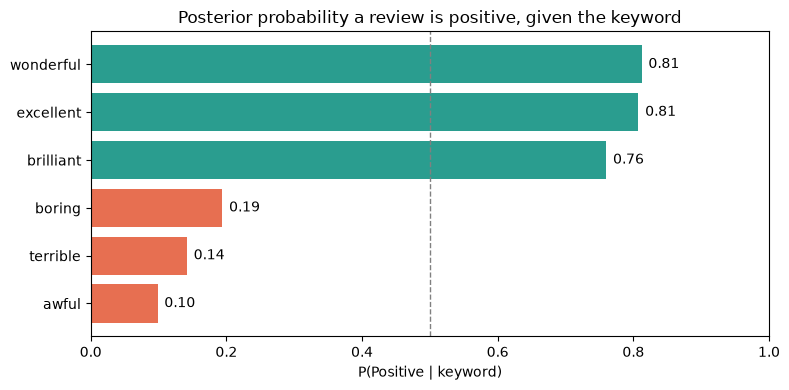

In [10]:
import matplotlib.pyplot as plt

order = sorted(results, key=lambda k: results[k]["posterior"])
posteriors = [results[k]["posterior"] for k in order]
colors = ["#2a9d8f" if p >= 0.5 else "#e76f51" for p in posteriors]

plt.figure(figsize=(8, 4))
plt.barh(order, posteriors, color=colors)
plt.axvline(0.5, linestyle="--", color="gray", linewidth=1)
for i, p in enumerate(posteriors):
    plt.text(p + 0.01, i, f"{p:.2f}", va="center")
plt.xlim(0, 1)
plt.xlabel("P(Positive | keyword)")
plt.title("Posterior probability a review is positive, given the keyword")
plt.tight_layout()
plt.show()

## What the results mean

- The **prior is exactly 0.5** because the dataset is balanced (25,000 positive / 25,000 negative).
  With no word information, a review is a coin flip.
- Each keyword then **moves us away from 0.5**. "wonderful" pushes the probability up to ~0.81;
  "awful" pushes it down to ~0.10. The word is *evidence* that updates our belief — that is exactly
  what a posterior is.
- Positive keywords cluster at **0.76–0.81**, negative keywords at **0.10–0.19**. The clean gap is
  the proof that keyword-based Bayesian classification separates the two classes.


